# **07 - Quality-adjusted price index and its forecast**

The sample has about 100,000 records per year and is not proportional to the market, so raw monthly medians mix a price effect with a **composition effect** (the mix of districts, building types, areas and ages changes from month to month). This notebook first builds a quality-adjusted index per track and then forecasts the index.

**Step 1 - hedonic time-dummy index.** `log1p(target)` is regressed on month dummies plus structural controls (`district_name`, `building_type`, `contract_type`, `renewal_right_used`, `log_area`, `floor` median-imputed, `floor_missing`, `building_age`). The month coefficients, exponentiated and rebased to 100 at 2022-01, form the index. Controls that are exactly redundant are dropped automatically (reported below). Two versions: **TRAIN-only** (months 2022-01..2024-12), used for all evaluation before 2025, and **full** (all 48 months), used as the oracle for 2025 and for the final projection.

**Step 2 - forecasting the index.** Candidates (fit on the log of the index): naive, seasonal naive, drift, linear trend, ETS with damped trend, ARIMA, SARIMA and Theta. ARIMA uses a drift and d = 1 with (p, q) in {0, 1, 2}^2 chosen by AIC; SARIMA uses d = 1, D = 1, seasonal period 12, (p, q) in {0, 1}^2 and seasonal AR in {0, 1}, chosen by AIC (the differencing orders are fixed because AIC is not comparable across them; the ADF tests below describe the series).

**Rolling-origin evaluation (pre-2025 only).** Origins every 3 months after months 18, 21, 24, 27, 30 and 33 of the 36 TRAIN months. The first origin is month 18 and not 24 so that the 12-month horizon is evaluated at three origins instead of one (only origin 24 or earlier leaves 12 target months inside TRAIN). Every origin uses an **index vintage** re-estimated with the months up to that origin only, so no future month enters any fit; the target is the TRAIN-only index. Selection rule fixed before looking at the results: lowest mean MAPE over the horizons 1, 3, 6 and 12.

**Step 3 - projection 2026-2028.** From the full index, with 80% and 95% intervals, for the selected candidate and for the linear-trend and damped-ETS alternatives. These are **extrapolation scenarios from 48 months of data**, not forecasts with demonstrated accuracy at that horizon.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rent_model import config
from rent_model.data import load_clean
from rent_model.features import select_track
from rent_model.ts_index import (ALPHAS, CANDIDATES, adf_report, error_table, forecast, hedonic_index, log_index,
                                 rolling_origin_forecasts, save_ts_report, select_candidate)

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 170)
plt.rcParams['figure.dpi'] = 100
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_LAST = pd.Timestamp('2024-12-01')
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Step 1 - Hedonic time-dummy index

In [2]:
df = load_clean()
idx_train, idx_full, raw = {}, {}, {}
for track, spec in config.TRACKS.items():
    idx_train[track] = hedonic_index(df, track, last_month=TRAIN_LAST)
    idx_full[track] = hedonic_index(df, track)
    d = select_track(df, track)
    median = d.groupby('contract_month')[spec['target']].median()
    raw[track] = 100 * median / median.iloc[0]
    print(f"{track}: {len(idx_train[track])} TRAIN-only months, {len(idx_full[track])} months in the full index; "
          f"rows per month {idx_full[track]['n_rows'].min():,} to {idx_full[track]['n_rows'].max():,}; "
          f"controls kept {idx_full[track].attrs['n_controls']}, dropped as redundant: {idx_full[track].attrs['dropped_controls']}")

jeonse: 36 TRAIN-only months, 48 months in the full index; rows per month 2,378 to 4,975; controls kept 33, dropped as redundant: ['floor_missing']


wolse: 36 TRAIN-only months, 48 months in the full index; rows per month 3,369 to 6,079; controls kept 33, dropped as redundant: ['floor_missing']


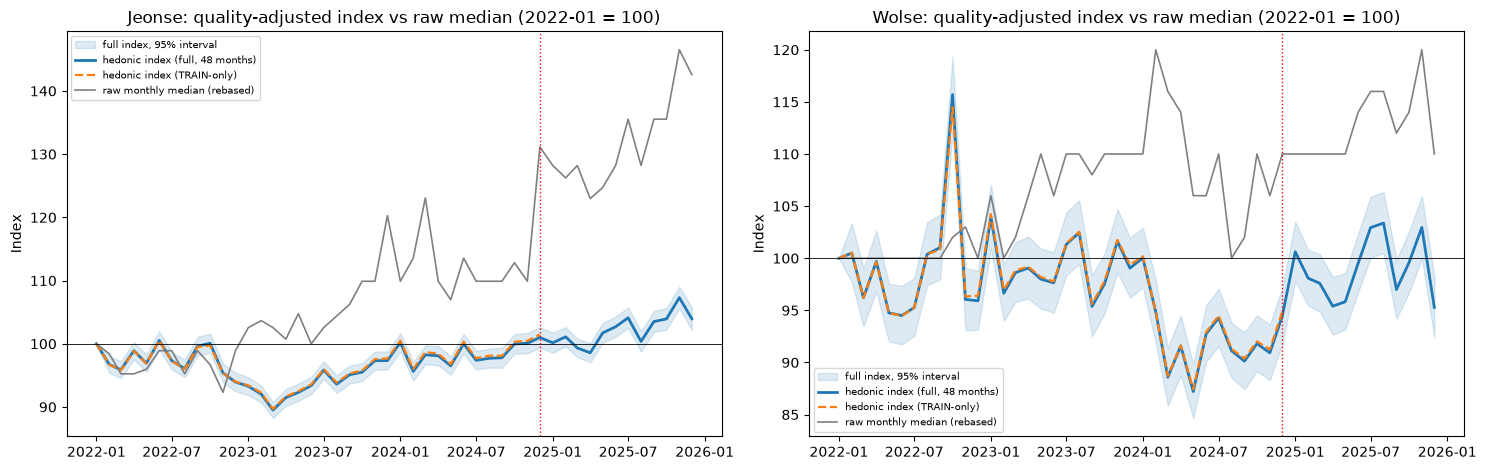

jeonse: index at 2024-12 = 100.99 (full) and 101.46 (TRAIN-only); index at 2025-12 = 103.96 (hedonic) vs 142.58 (raw median rebased)
jeonse: max |full - TRAIN-only| over 2022-01..2024-12 = 0.471 index points (mean 0.216)
jeonse: correlation of monthly changes hedonic vs raw median = 0.3162
jeonse: largest monthly gap hedonic - raw = 39.22 index points


,hedonic_full,hedonic_train_only,raw_median
2022-01-01,100.0000,100.0000,100.0000
2022-12-01,93.9400,93.9900,98.9000
2023-12-01,97.3400,97.6700,120.2800
2024-12-01,100.9900,101.4600,131.1400
2025-06-01,102.6900,NaN,128.2100
2025-12-01,103.9600,NaN,142.5800


wolse: index at 2024-12 = 94.47 (full) and 94.90 (TRAIN-only); index at 2025-12 = 95.28 (hedonic) vs 110.00 (raw median rebased)
wolse: max |full - TRAIN-only| over 2022-01..2024-12 = 1.238 index points (mean 0.198)
wolse: correlation of monthly changes hedonic vs raw median = 0.3923
wolse: largest monthly gap hedonic - raw = 27.42 index points


,hedonic_full,hedonic_train_only,raw_median
2022-01-01,100.0000,100.0000,100.0000
2022-12-01,95.9100,96.4000,100.0000
2023-12-01,99.0500,99.3800,110.0000
2024-12-01,94.4700,94.9000,110.0000
2025-06-01,99.5100,NaN,114.0000
2025-12-01,95.2800,NaN,110.0000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, track in zip(axes, config.TRACKS):
    full, train = idx_full[track], idx_train[track]
    ax.fill_between(full.index, full['index_low95'], full['index_high95'], color='tab:blue', alpha=0.15, label='full index, 95% interval')
    ax.plot(full.index, full['index'], color='tab:blue', lw=2, label='hedonic index (full, 48 months)')
    ax.plot(train.index, train['index'], color='tab:orange', lw=1.6, ls='--', label='hedonic index (TRAIN-only)')
    ax.plot(raw[track].index, raw[track].values, color='gray', lw=1.2, label='raw monthly median (rebased)')
    ax.axhline(100, color='black', lw=0.6); ax.axvline(TRAIN_LAST, color='red', ls=':', lw=1)
    ax.set_title(f'{track.capitalize()}: quality-adjusted index vs raw median (2022-01 = 100)')
    ax.set_ylabel('Index'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / '07_price_index.png', dpi=130); plt.show()

for track in config.TRACKS:
    full, train = idx_full[track], idx_train[track]
    comp = pd.DataFrame({'hedonic_full': full['index'], 'hedonic_train_only': train['index'], 'raw_median': raw[track]})
    revision = (full['index'].loc[train.index] - train['index']).abs()
    print(f"{track}: index at 2024-12 = {full['index'].loc[TRAIN_LAST]:.2f} (full) and {train['index'].iloc[-1]:.2f} (TRAIN-only); "
          f"index at 2025-12 = {full['index'].iloc[-1]:.2f} (hedonic) vs {raw[track].iloc[-1]:.2f} (raw median rebased)")
    print(f"{track}: max |full - TRAIN-only| over 2022-01..2024-12 = {revision.max():.3f} index points (mean {revision.mean():.3f})")
    print(f"{track}: correlation of monthly changes hedonic vs raw median = {comp['hedonic_full'].pct_change().corr(comp['raw_median'].pct_change()):.4f}")
    print(f"{track}: largest monthly gap hedonic - raw = {(comp['hedonic_full'] - comp['raw_median']).abs().max():.2f} index points")
    display(comp.iloc[[0, 11, 23, 35, 41, 47]].round(2))

**Interpretation.** The quality-adjusted index and the raw median tell different stories, which confirms the composition effect. In Jeonse the hedonic index is 93.94 at 2022-12, 97.34 at 2023-12, 100.99 at 2024-12 and 103.96 at 2025-12, while the raw monthly median rebased to 2022-01 is 98.90, 120.28, 131.14 and 142.58. In Wolse the hedonic index is 95.91, 99.05, 94.47 and 95.28, against 100.00, 110.00, 110.00 and 110.00 for the raw median (a step series because Wolse medians take few distinct values). The correlation between the monthly changes of the hedonic index and of the raw median is only 0.3162 (Jeonse) and 0.3923 (Wolse), and the largest monthly gap between them is 39.22 and 27.42 index points. Most of the apparent rise of the raw median therefore comes from what is sold each month, not from the price of a comparable unit. Re-estimating the index with the 48 months changes the 2022-2024 values very little: the maximum absolute difference between the TRAIN-only and the full index is 0.471 index points in Jeonse and 1.238 in Wolse (means 0.216 and 0.198). `floor_missing` is dropped automatically as an exact linear combination of the other controls. The controls are structural and district-level; neighbourhood, building quality and unobserved attributes are not controlled, so the index is a quality-adjusted measure and not a causal price effect.

### Stationarity checks (ADF on the log index)

In [4]:
adf_rows = []
for track in config.TRACKS:
    for version, table in [('TRAIN-only', idx_train[track]), ('full', idx_full[track])]:
        y = log_index(table)
        for label, series, reg in [('level (constant)', y, 'c'), ('level (constant+trend)', y, 'ct'), ('first difference', y.diff().dropna(), 'c')]:
            adf_rows.append({'track': track, 'index': version, 'series': label, **adf_report(series, reg)})
adf = pd.DataFrame(adf_rows).set_index(['track', 'index', 'series'])
display(adf)

adf_stat  p_value  lags_used  n_obs  critical_5pct
track  index      series                                                                    
jeonse TRAIN-only level (constant)         -1.2983   0.6299          1     34        -2.9512
                  level (constant+trend)   -1.6076   0.7894          1     34        -3.5486
                  first difference         -8.3909   0.0000          0     34        -2.9512
       full       level (constant)         -0.8830   0.7935          1     46        -2.9268
                  level (constant+trend)   -3.2503   0.0748          0     47        -3.5084
                  first difference         -9.7769   0.0000          0     46        -2.9268
wolse  TRAIN-only level (constant)         -1.6510   0.4565          2     33        -2.9541
                  level (constant+trend)   -2.5726   0.2927          3     32        -3.5579
                  first difference         -6.3180   0.0000          1     33        -2.9541
       full       level (constant)         -1.7507   0.4052          7     40        -2.9371
                  level (constant+trend)   -1.8259   0.6921          7     40        -3.5266
                  first difference         -4.8586   0.0000          3     43        -2.9315

**Interpretation.** No level series rejects a unit root at the 5% level, with one near miss: the p-values of the level tests are between 0.2927 and 0.7935, except the full Jeonse index with constant and trend (statistic -3.2503 against a critical value of -3.5084, p-value 0.0748). All first differences reject the unit root (p-values of 0.0000). The results are consistent with treating the log index as integrated of order one (the choice d = 1 in ARIMA and SARIMA), but the samples have only 32 to 47 observations, so the tests have low power and cannot distinguish a unit root from slow mean reversion.

## Step 2 - Forecasting the index: rolling-origin evaluation (pre-2025)

In [5]:
rolling, tables, selected = {}, {}, {}
for track in config.TRACKS:
    rolling[track] = rolling_origin_forecasts(df, track, idx_train[track])
    tables[track] = error_table(rolling[track])
    selected[track] = select_candidate(tables[track])
    origins = sorted(rolling[track]['n_observed'].unique())
    print(f"{track}: origins (months observed) {origins}; forecasts per candidate {int(rolling[track].groupby('candidate').size().iloc[0])}; "
          f"failed fits: {int(rolling[track]['forecast'].isna().sum())}")
    print(f'{track}: candidate table (MAE in index points, MAPE in %, n_evals = number of origins with that horizon)')
    display(tables[track].sort_values(('MAPE', 'mean_h')))
    print(f"{track}: selected candidate (lowest mean MAPE over horizons 1, 3, 6, 12) = {selected[track]}")

jeonse: origins (months observed) [np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(30), np.int64(33)]; forecasts per candidate 54; failed fits: 0
jeonse: candidate table (MAE in index points, MAPE in %, n_evals = number of origins with that horizon)


MAE                         MAPE                       n_evals            MAPE
horizon             1      3      6      12      1      3      6      12       1  3  6 12 mean_h
candidate                                                                                       
naive          1.8781 2.2086 2.5146  4.6899 1.9090 2.2362 2.5413  4.6831       6  6  5  3 2.8424
arima          1.8425 2.3101 2.8793  5.7362 1.8731 2.3412 2.9113  5.7358       6  6  5  3 3.2154
theta          1.9887 2.5056 3.4667  6.8575 2.0243 2.5425 3.5012  6.8557       6  6  5  3 3.7309
drift          2.0013 2.6350 3.3071  7.5606 2.0364 2.6750 3.3468  7.5615       6  6  5  3 3.9049
seasonal_naive 4.3221 5.1140 5.3253  4.6899 4.3788 5.1801 5.3632  4.6831       6  6  5  3 4.9013
sarima         2.7539 3.4785 7.0253  6.4763 2.8078 3.5405 7.1179  6.5054       6  6  5  3 4.9929
ets_damped     2.9933 3.5343 4.7283  8.9621 3.0475 3.5957 4.7729  8.9595       6  6  5  3 5.0939
linear_trend   3.9660 4.7683 6.6251 10.9800 4.0334 4.8375 6.6801 10.9778       6  6  5  3 6.6322

jeonse: selected candidate (lowest mean MAPE over horizons 1, 3, 6, 12) = naive


wolse: origins (months observed) [np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(30), np.int64(33)]; forecasts per candidate 54; failed fits: 0
wolse: candidate table (MAE in index points, MAPE in %, n_evals = number of origins with that horizon)


MAE                        MAPE                      n_evals            MAPE
horizon             1      3      6     12      1      3      6     12       1  3  6 12 mean_h
candidate                                                                                     
drift          2.9881 4.9804 4.7729 2.7071 3.1178 5.3683 5.1659 2.9112       6  6  5  3 4.1408
naive          2.7482 4.7224 4.0730 4.4265 2.8638 5.1046 4.4299 4.7845       6  6  5  3 4.2957
linear_trend   1.8152 3.9277 5.0157 6.8136 1.9105 4.3043 5.5304 7.3914       6  6  5  3 4.7842
ets_damped     2.2942 3.7972 5.4755 6.7307 2.4191 4.1473 6.0212 7.3021       6  6  5  3 4.9724
sarima         4.5559 6.8385 4.0061 4.7034 4.6830 7.3205 4.3795 5.0211       6  6  5  3 5.3510
arima          2.5968 4.0132 6.0062 7.1721 2.7417 4.3757 6.5755 7.7786       6  6  5  3 5.3679
theta          2.3294 4.2233 6.1685 7.5201 2.4713 4.5955 6.7627 8.1533       6  6  5  3 5.4957
seasonal_naive 7.8761 5.4060 5.2718 4.4265 8.1848 5.8508 5.7503 4.7845       6  6  5  3 6.1426

wolse: selected candidate (lowest mean MAPE over horizons 1, 3, 6, 12) = drift


**Interpretation.** The simplest methods win. In Jeonse the naive forecast has the lowest mean MAPE over the four horizons (2.8424%), ahead of ARIMA (3.2154%), Theta (3.7309%) and drift (3.9049%); the linear trend is the worst (6.6322%), and at the 12-month horizon its MAPE is 10.9778% against 4.6831% for the naive forecast, so extrapolating a fitted trend adds error. In Wolse drift is selected (4.1408%), very close to naive (4.2957%); at 12 months drift has an MAE of 2.7071 index points (MAPE 2.9112%) against 4.4265 (4.7845%) for naive. Seasonal naive coincides with naive at the 12-month horizon by construction. The evidence is thin: the `n_evals` columns show that the 12-month errors rest on 3 overlapping origins and the 6-month errors on 5, and the gaps among the leading candidates (for example 2.8424% against 3.2154% in Jeonse, 4.1408% against 4.2957% in Wolse) are small compared with the variation across horizons. SARIMA, whose seasonal differencing is estimated on 18 to 33 observations, is in the lower half in both tracks (mean MAPE 4.9929% and 5.3510%). No fit failed.

## 2025 test: TRAIN-only forecast vs the oracle index

jeonse: oracle index 2025-01 = 100.15, 2025-12 = 103.96; TRAIN-only index at 2024-12 = 101.46; selected before 2025: naive


,MAE_pts,MAPE_pct,mean_signed_gap_pct,gap_2025_12_pts,gap_2025_12_pct,oracle_in_80,oracle_in_95
candidate,,,,,,,
naive,2.0630,2.0006,-0.6968,-2.4941,-2.3992,12,12
seasonal_naive,3.3760,3.2648,-3.2066,-2.4941,-2.3992,12,12
drift,1.9155,1.8616,-0.4314,-1.9882,-1.9126,12,12
linear_trend,3.6637,3.5363,-3.5363,-4.9850,-4.7954,7,11
ets_damped,2.1777,2.1035,-1.2078,-3.0171,-2.9023,11,12
arima,1.7196,1.6744,-0.2262,-1.3903,-1.3374,12,12
sarima,2.0696,2.0315,0.2687,1.1565,1.1125,11,12
theta,2.0080,1.9433,-0.8981,-2.4891,-2.3944,12,12


wolse: oracle index 2025-01 = 100.62, 2025-12 = 95.28; TRAIN-only index at 2024-12 = 94.90; selected before 2025: drift


,MAE_pts,MAPE_pct,mean_signed_gap_pct,gap_2025_12_pts,gap_2025_12_pct,oracle_in_80,oracle_in_95
candidate,,,,,,,
naive,4.1119,4.0743,-4.0743,-0.3793,-0.3981,12,12
seasonal_naive,6.5074,6.5197,-6.5197,-0.3793,-0.3981,7,11
drift,5.0289,4.9993,-4.9993,-2.0675,-2.1700,12,12
linear_trend,7.8412,7.8408,-7.8408,-5.3782,-5.6447,4,9
ets_damped,6.3400,6.3264,-6.3264,-2.6074,-2.7366,7,12
arima,8.0127,8.0148,-8.0148,-5.2663,-5.5272,4,8
sarima,12.8619,12.9413,-12.9413,-6.8984,-7.2402,1,5
theta,7.3365,7.3322,-7.3322,-4.2436,-4.4539,11,11


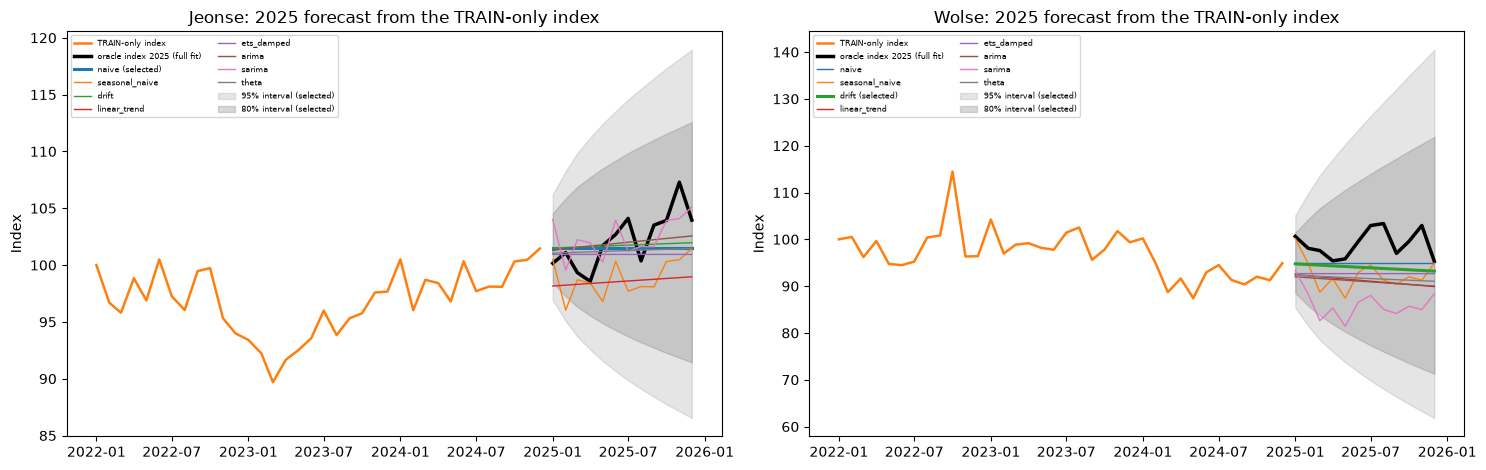

In [6]:
y_train = {t: log_index(idx_train[t]) for t in config.TRACKS}
oracle = {t: idx_full[t]['index'].loc['2025-01-01':'2025-12-01'] for t in config.TRACKS}
forecasts_2025, gap_rows = {}, []
for track in config.TRACKS:
    for name in CANDIDATES:
        f = forecast(name, y_train[track], 12, ALPHAS)
        fi = np.exp(f)
        forecasts_2025[(track, name)] = fi
        o = oracle[track]
        gap = fi['mean'].to_numpy() - o.to_numpy()
        gap_rows.append({'track': track, 'candidate': name, 'MAE_pts': np.abs(gap).mean(),
                         'MAPE_pct': (np.abs(gap) / o.to_numpy()).mean() * 100,
                         'mean_signed_gap_pct': (gap / o.to_numpy()).mean() * 100,
                         'gap_2025_12_pts': gap[-1], 'gap_2025_12_pct': gap[-1] / o.iloc[-1] * 100,
                         'oracle_in_80': int(((o.to_numpy() >= fi['lo80']) & (o.to_numpy() <= fi['hi80'])).sum()),
                         'oracle_in_95': int(((o.to_numpy() >= fi['lo95']) & (o.to_numpy() <= fi['hi95'])).sum())})
gap_table = pd.DataFrame(gap_rows).set_index(['track', 'candidate'])
for track in config.TRACKS:
    print(f"{track}: oracle index 2025-01 = {oracle[track].iloc[0]:.2f}, 2025-12 = {oracle[track].iloc[-1]:.2f}; "
          f"TRAIN-only index at 2024-12 = {idx_train[track]['index'].iloc[-1]:.2f}; selected before 2025: {selected[track]}")
    display(gap_table.loc[track])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, track in zip(axes, config.TRACKS):
    train, full = idx_train[track], idx_full[track]
    ax.plot(train.index, train['index'], color='tab:orange', lw=1.8, label='TRAIN-only index')
    ax.plot(full.loc['2025-01-01':].index, full.loc['2025-01-01':, 'index'], color='black', lw=2.5, label='oracle index 2025 (full fit)')
    for name in CANDIDATES:
        fi = forecasts_2025[(track, name)]
        ax.plot(fi.index, fi['mean'], lw=2.2 if name == selected[track] else 1.0, label=name + (' (selected)' if name == selected[track] else ''))
    best = forecasts_2025[(track, selected[track])]
    ax.fill_between(best.index, best['lo95'], best['hi95'], color='gray', alpha=0.2, label='95% interval (selected)')
    ax.fill_between(best.index, best['lo80'], best['hi80'], color='gray', alpha=0.3, label='80% interval (selected)')
    ax.set_title(f'{track.capitalize()}: 2025 forecast from the TRAIN-only index'); ax.set_ylabel('Index'); ax.legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / '07_forecast_2025.png', dpi=130); plt.show()

**Interpretation.** Jeonse: the TRAIN-only index ends at 101.46 in 2024-12 and the oracle index (fitted on all 48 months) goes from 100.15 in 2025-01 to 103.96 in 2025-12. The candidate selected before 2025 (naive, a flat forecast at 101.46) has an MAE of 2.0630 index points and a MAPE of 2.0006% against the oracle, a mean signed gap of -0.6968% and a gap of -2.4941 points (-2.3992%) in 2025-12; the oracle lies inside its 80% interval in all 12 months. Chosen with hindsight, ARIMA would have had the lowest 2025 MAPE (1.6744%) and the linear trend the highest (3.5363%, with the oracle inside the 80% interval in 7 months), but the selection used only pre-2025 data. Wolse: the oracle index goes from 94.47 in 2024-12 to 100.62 in 2025-01 and ends at 95.28 in 2025-12, a level shift that no TRAIN-only trend can anticipate. The selected candidate (drift) has an MAE of 5.0289 points, a MAPE of 4.9993%, a mean signed gap of -4.9993% (the forecast is below the oracle on average) and a gap of -2.0675 points (-2.1700%) in 2025-12, with the oracle inside the 80% interval in 12 months. In 2025 naive would have been better (MAPE 4.0743%) and the trend models worse (ARIMA 8.0148%, linear trend 7.8408%, SARIMA 12.9413%). The gaps are mostly forecast error and not index re-estimation: the TRAIN-only index differs from the full one by at most 0.471 (Jeonse) and 1.238 (Wolse) points over 2022-2024.

## Step 3 - Extrapolation scenarios 2026-2028 (index fitted on all 48 months)

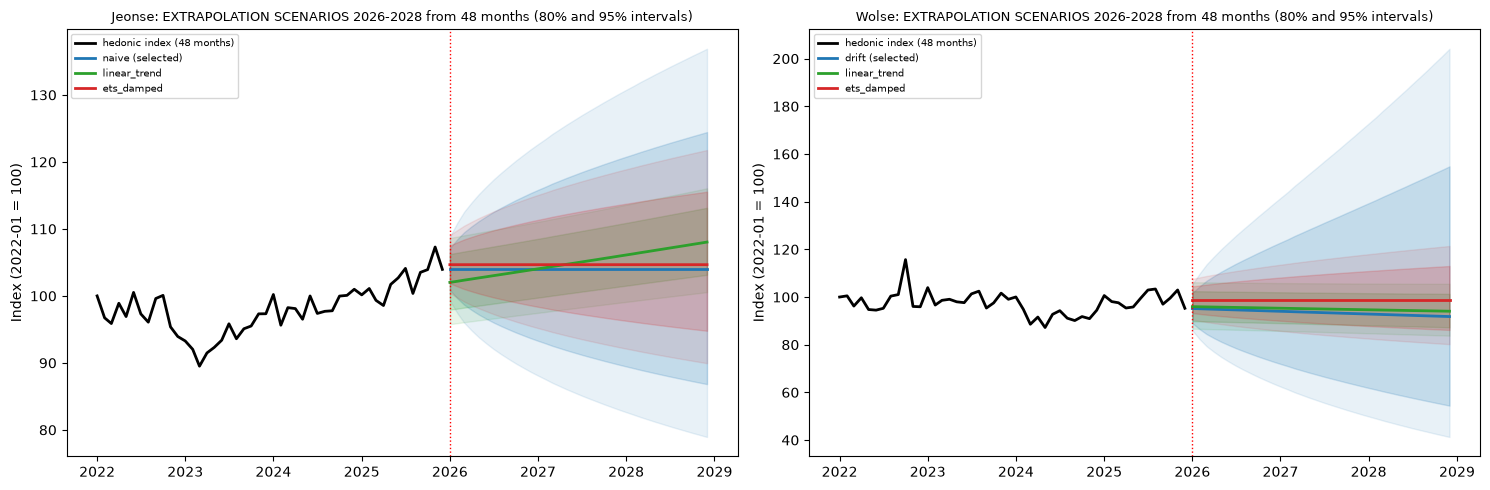

jeonse: scenarios (index points; 2025-12 = 103.96); extrapolation from 48 months


mean     lo80     hi80     lo95     hi95  change_vs_2025-12_pct
scenario     month                                                                      
naive        2026-12 103.9600  93.7000 115.3400  88.6800 121.8600                 0.0000
             2027-12 103.9600  89.7500 120.4100  83.0300 130.1500                 0.0000
             2028-12 103.9600  86.8300 124.4500  78.9400 136.8900                 0.0000
linear_trend 2026-12 103.8700  99.6000 108.3300  97.3300 110.8500                -0.0800
             2027-12 105.9300 101.3800 110.6900  98.9700 113.3900                 1.9000
             2028-12 108.0400 103.1500 113.1600 100.5600 116.0600                 3.9300
ets_damped   2026-12 104.6600  98.5800 111.1200  95.5100 114.6900                 0.6800
             2027-12 104.6600  96.4400 113.5900  92.3500 118.6100                 0.6800
             2028-12 104.6600  94.8000 115.5600  89.9600 121.7700                 0.6800

wolse: scenarios (index points; 2025-12 = 95.28); extrapolation from 48 months


mean    lo80     hi80    lo95     hi95  change_vs_2025-12_pct
scenario     month                                                                   
drift        2026-12 94.1100 72.9300 121.4400 63.7200 138.9900                -1.2300
             2027-12 92.9500 62.6200 137.9800 50.8100 170.0700                -2.4400
             2028-12 91.8100 54.4500 154.8200 41.2900 204.1600                -3.6400
linear_trend 2026-12 95.3600 89.1200 102.0300 85.8700 105.8900                 0.0800
             2027-12 94.7000 88.2300 101.6400 84.8700 105.6600                -0.6100
             2028-12 94.0500 87.2900 101.3300 83.8000 105.5500                -1.2900
ets_damped   2026-12 98.7000 90.2600 107.9100 86.1000 113.1400                 3.5900
             2027-12 98.7000 88.0000 110.6900 82.8100 117.6200                 3.5900
             2028-12 98.7000 86.1900 113.0100 80.2300 121.4100                 3.5900

In [7]:
y_full = {t: log_index(idx_full[t]) for t in config.TRACKS}
scenario_names = {t: list(dict.fromkeys([selected[t], 'linear_trend', 'ets_damped'])) for t in config.TRACKS}
projection = {}
for track in config.TRACKS:
    for name in scenario_names[track]:
        projection[(track, name)] = np.exp(forecast(name, y_full[track], 36, ALPHAS))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, track in zip(axes, config.TRACKS):
    full = idx_full[track]
    ax.plot(full.index, full['index'], color='black', lw=2, label='hedonic index (48 months)')
    for name, color in zip(scenario_names[track], ['tab:blue', 'tab:green', 'tab:red']):
        p = projection[(track, name)]
        ax.plot(p.index, p['mean'], color=color, lw=2, label=name + (' (selected)' if name == selected[track] else ''))
        ax.fill_between(p.index, p['lo95'], p['hi95'], color=color, alpha=0.10)
        ax.fill_between(p.index, p['lo80'], p['hi80'], color=color, alpha=0.18)
    ax.axvline(pd.Timestamp('2026-01-01'), color='red', ls=':', lw=1)
    ax.set_title(f'{track.capitalize()}: EXTRAPOLATION SCENARIOS 2026-2028 from 48 months (80% and 95% intervals)', fontsize=9)
    ax.set_ylabel('Index (2022-01 = 100)'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / '07_scenarios_2026_2028.png', dpi=130); plt.show()

for track in config.TRACKS:
    rows = []
    for name in scenario_names[track]:
        p = projection[(track, name)]
        for month in ['2026-12-01', '2027-12-01', '2028-12-01']:
            r = p.loc[month]
            rows.append({'scenario': name, 'month': month[:7], 'mean': r['mean'], 'lo80': r['lo80'], 'hi80': r['hi80'], 'lo95': r['lo95'], 'hi95': r['hi95'],
                         'change_vs_2025-12_pct': (r['mean'] / idx_full[track]['index'].iloc[-1] - 1) * 100})
    print(f"{track}: scenarios (index points; 2025-12 = {idx_full[track]['index'].iloc[-1]:.2f}); extrapolation from 48 months")
    display(pd.DataFrame(rows).set_index(['scenario', 'month']).round(2))

**Interpretation.** These are extrapolation scenarios from 48 months; none has been evaluated at horizons beyond 12 months, and 2026-2028 means 25 to 36 months ahead. In Jeonse the selected naive scenario stays flat at 103.96, with a 95% interval of 78.94 to 136.89 in 2028-12; the linear trend reaches 108.04 in 2028-12 (3.93% above 2025-12) with a much narrower 95% interval (100.56 to 116.06), although it was the worst candidate in the rolling-origin evaluation, so its narrow interval understates the uncertainty; the damped ETS is flat at 104.66. In Wolse the scenarios disagree in direction: drift goes down to 91.81 in 2028-12 (-3.64%) with a 95% interval of 41.29 to 204.16, the linear trend to 94.05 (-1.29%) and the damped ETS up to 98.70 (+3.59%). The width of the intervals shows that 48 months of data do not support a precise projection of the level, and the Wolse index is noisy from month to month.

## Save index and forecast tables

In [8]:
errors_flat = {}
for track in config.TRACKS:
    flat = tables[track].round(6).copy()
    flat.columns = [f'{a}_{b}' for a, b in flat.columns]
    errors_flat[track] = flat
for track in config.TRACKS:
    report = {
        'description': 'Hedonic time-dummy index (2022-01 = 100) and forecasts of the index. Scenarios 2026-2028 are extrapolations from 48 months.',
        'controls_dropped_as_redundant': idx_full[track].attrs['dropped_controls'],
        'index_train_only': idx_train[track][['index', 'index_low95', 'index_high95', 'n_rows']],
        'index_full': idx_full[track][['index', 'index_low95', 'index_high95', 'n_rows']],
        'raw_median_rebased': raw[track],
        'rolling_origin': {'origins_months_observed': [int(x) for x in sorted(rolling[track]['n_observed'].unique())],
                           'selection_rule': 'lowest mean MAPE over horizons 1, 3, 6, 12',
                           'selected': selected[track],
                           'errors': errors_flat[track]},
        'comparison_2025_vs_oracle': {'selected_before_2025': selected[track], 'table': gap_table.loc[track]},
        'forecast_2025_from_train_only': {name: forecasts_2025[(track, name)] for name in CANDIDATES},
        'scenarios_2026_2028': {name: projection[(track, name)] for name in scenario_names[track]},
        'adf': adf.loc[track].reset_index().to_dict(orient='records'),
    }
    print(save_ts_report(track, report).relative_to(config.ROOT))
print('Figures:', sorted(p.name for p in config.FIGURES_DIR.glob('07_*.png')))

reports\metrics\ts_index_jeonse.json
reports\metrics\ts_index_wolse.json
Figures: ['07_forecast_2025.png', '07_price_index.png', '07_scenarios_2026_2028.png']


## Summary

In [9]:
summary = pd.DataFrame({
    track: {'selected candidate (pre-2025)': selected[track],
            'MAE at h=12 (index pts, rolling origin)': tables[track].loc[selected[track], ('MAE', 12)],
            'MAPE at h=12 (%, rolling origin)': tables[track].loc[selected[track], ('MAPE', 12)],
            'MAPE 2025 vs oracle (%)': gap_table.loc[(track, selected[track]), 'MAPE_pct'],
            'mean signed gap 2025 (%)': gap_table.loc[(track, selected[track]), 'mean_signed_gap_pct'],
            'gap at 2025-12 (index pts)': gap_table.loc[(track, selected[track]), 'gap_2025_12_pts']}
    for track in config.TRACKS})
display(summary)

,jeonse,wolse
selected candidate (pre-2025),naive,drift
"MAE at h=12 (index pts, rolling origin)",4.6899,2.7071
"MAPE at h=12 (%, rolling origin)",4.6831,2.9112
MAPE 2025 vs oracle (%),2.0006,4.9993
mean signed gap 2025 (%),-0.6968,-4.9993
gap at 2025-12 (index pts),-2.4941,-2.0675


## Conclusion

- **Index.** The quality-adjusted index is almost flat over 2022-2025 in both tracks (Jeonse 103.96 and Wolse 95.28 in 2025-12), whereas the raw monthly median rebased reaches 142.58 and 110.00: raw medians mostly reflect the changing mix of the sample.
- **Best candidate.** Jeonse: naive (12-month MAE 4.6899 index points, MAPE 4.6831%); Wolse: drift (12-month MAE 2.7071 points, MAPE 2.9112%). These errors come from only 3 overlapping origins and the margin over the next candidates is small.
- **2025.** Against the oracle index the selected forecasts have a MAPE of 2.0006% (Jeonse) and 4.9993% (Wolse), and gaps of -2.4941 and -2.0675 index points in 2025-12. The Wolse 2025 level shift (94.47 to 100.62 between 2024-12 and 2025-01) was not anticipated.
- **2026-2028.** Scenarios only: the intervals are wide and, in Wolse, the scenarios do not agree on the direction.